In [1]:
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
from napari_spatialdata import Interactive
import matplotlib.pyplot as plt
import seaborn as sns
import squidpy as sq

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribut

In [11]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from anndata import AnnData
from scipy.sparse import csr_matrix
from functools import partial
from spatialdata._logging import logger as logg

from squidpy._constants._pkg_constants import Key
from squidpy.read._utils import PathLike, _load_image, _read_counts

__all__ = ["visium", "vizgen", "nanostring"]


def visium(
    path: PathLike,
    *,
    counts_file: str = "filtered_feature_bc_matrix.h5",
    library_id: str | None = None,
    load_images: bool = True,
    source_image_path: PathLike | None = None,
    **kwargs: Any,
) -> AnnData:
    """
    Read *10x Genomics* Visium formatted dataset.

    In addition to reading the regular *Visium* output, it looks for the *spatial* directory and loads the images,
    spatial coordinates and scale factors.

    .. seealso::

        - `Space Ranger output <https://support.10xgenomics.com/spatial-gene-expression/software/pipelines/latest/output/overview>`_.
        - :func:`squidpy.pl.spatial_scatter` on how to plot spatial data.

    Parameters
    ----------
    path
        Path to the root directory containing *Visium* files.
    counts_file
        Which file in the passed directory to use as the count file. Typically either *filtered_feature_bc_matrix.h5* or
        *raw_feature_bc_matrix.h5*.
    library_id
        Identifier for the *Visium* library. Useful when concatenating multiple :class:`anndata.AnnData` objects.
    kwargs
        Keyword arguments for :func:`scanpy.read_10x_h5`, :func:`scanpy.read_10x_mtx` or :func:`anndata.io.read_text`.

    Returns
    -------
    Annotated data object with the following keys:

        - :attr:`anndata.AnnData.obsm` ``['spatial']`` - spatial spot coordinates.
        - :attr:`anndata.AnnData.uns` ``['spatial']['{library_id}']['images']`` - *hires* and *lowres* images.
        - :attr:`anndata.AnnData.uns` ``['spatial']['{library_id}']['scalefactors']`` - scale factors for the spots.
        - :attr:`anndata.AnnData.uns` ``['spatial']['{library_id}']['metadata']`` - various metadata.
    """  # noqa: E501
    path = Path(path)
    adata, library_id = _read_counts(path, counts_file=counts_file, library_id=library_id, **kwargs)

    if not load_images:
        return adata

    adata.uns[Key.uns.spatial][library_id][Key.uns.image_key] = {
        res: _load_image(path / f"{Key.uns.spatial}/tissue_{res}_image.png") for res in ["hires", "lowres"]
    }
    adata.uns[Key.uns.spatial][library_id]["scalefactors"] = json.loads(
        (path / f"{Key.uns.spatial}/scalefactors_json.json").read_bytes()
    )

    # Space Ranger versions use different file formats:
    #   - v1: tissue_positions.csv (no header)
    #   - v2: tissue_positions_list.csv (with header)
    #   - v3: tissue_positions.csv (with header)
    # tissue_positions_file = (
    #     path / "spatial/tissue_positions.csv"
    #     if (path / "spatial/tissue_positions.csv").exists()
    #     else path / "spatial/tissue_positions_list.csv"
    # )
    
    # Read parquet file
    if (path / "spatial" / "tissue_positions.parquet").exists(): 
        read_coords = partial(pd.read_parquet)
        tissue_positions_file = path / "spatial" / "tissue_positions.parquet"
    else:
        raise ValueError(f"Cannot find `tissue_positions` file in `{path}`.")
    coords = read_coords(tissue_positions_file).set_index("barcode")

    # Detect header by checking if first cell is 'barcode' (header) or a barcode value
    # with open(tissue_positions_file) as f:
    #     first_cell = f.readline().split(",")[0].strip()
    # has_header = first_cell.lower() == "barcode"

    # coords = pd.read_csv(
    #     tissue_positions_file,
    #     header=0 if has_header else None,
    #     index_col=0,
    # )
    coords.columns = ["in_tissue", "array_row", "array_col", "pxl_col_in_fullres", "pxl_row_in_fullres"]
    # https://github.com/scverse/squidpy/issues/657
    # coords.set_index(coords.index.astype(adata.obs.index.dtype), inplace=True)

    adata.obs = pd.merge(adata.obs, coords, how="left", left_index=True, right_index=True)
    adata.obsm[Key.obsm.spatial] = adata.obs[["pxl_row_in_fullres", "pxl_col_in_fullres"]].values
    adata.obs.drop(columns=["pxl_row_in_fullres", "pxl_col_in_fullres"], inplace=True)

    if source_image_path is not None:
        source_image_path = Path(source_image_path).absolute()
        if not source_image_path.exists():
            logg.warning(f"Path to the high-resolution tissue image `{source_image_path}` does not exist")
        adata.uns["spatial"][library_id]["metadata"]["source_image_path"] = str(source_image_path)

    return adata


In [12]:
sdata = visium('../data/Visium_HD_Lung_ILA010/binned_outputs/square_008um/')


/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [14]:
sq.gr.spatial_neighbors(sdata, n_rings=1, coord_type="grid", n_neighs=8)

In [15]:
sdata.obsp["spatial_distances"]


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3978538 stored elements and shape (512676, 512676)>

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


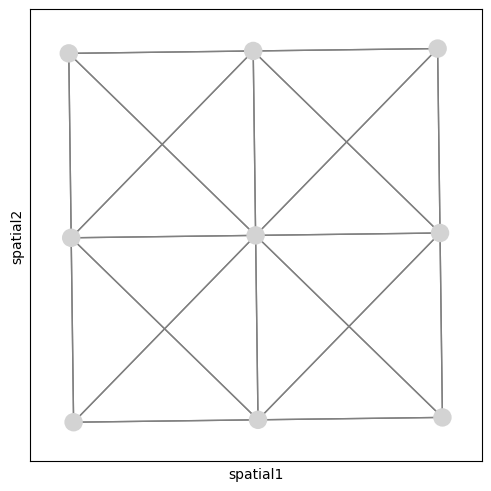

In [19]:
_, idx = sdata.obsp["spatial_connectivities"][420, :].nonzero()
idx = np.append(idx, 420)
sq.pl.spatial_scatter(
    sdata[idx, :],
    connectivity_key="spatial_connectivities",
    img=False,
    na_color="lightgrey",
    size=0.1
)

In [45]:
# Read in deconvolution proportions (tsv file)
deconv_proportions = pd.read_csv('Visium_HD_Lung_ILA010_008um_filtered100UMI/proportions_rctd_Visium_HD_Lung_ILA010_008um_filtered100UMI', sep='\t',
                                header=0, index_col=None)

In [25]:
# Get total counts per spot
total_counts = sdata.X.sum(axis=1).A1 if isinstance(sdata.X, csr_matrix) else sdata.X.sum(axis=1)
sdata.obs['total_counts'] = total_counts

In [26]:
sdata.obs

,in_tissue,array_row,array_col,total_counts
s_008um_00269_00526-1,1,269,526,46.0
s_008um_00260_00253-1,1,260,253,48.0
s_008um_00433_00599-1,1,433,599,209.0
s_008um_00266_00304-1,1,266,304,523.0
s_008um_00154_00449-1,1,154,449,66.0
...,...,...,...,...
s_008um_00214_00470-1,1,214,470,43.0
s_008um_00068_00328-1,1,68,328,18.0
s_008um_00655_00060-1,1,655,60,186.0
s_008um_00307_00022-1,1,307,22,156.0


In [27]:
# Remove sdata where total counts is less than 100
sdata = sdata[sdata.obs['total_counts'] > 100, :]

In [29]:
sdata.n_obs == deconv_proportions.shape[0]

True

In [46]:
deconv_proportions

,Art_BEC,AT1_cells,AT2_cells,Bcells,Cap_BEC,Car4_BEC,CD4_Tcells,Cilliated,Dendriticcells,Fibroblasts,...,Lymph_endo,Macrophages,Mesothelium,NK_CD8,Plasma_cells,Resident_Tcells,Secretory,Tcells,Tregs,Venous_BEC
0,0.0,0.0,0.096604,0.000000,0.0,0.903396,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000
1,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.494473,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.505527,0.0,0.0,0.000000
2,0.0,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000
3,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.609355,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.390645,0.0,0.0,0.000000
4,0.0,0.0,0.407157,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.592843,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143652,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,1.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000
143653,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.386429,...,0.0,0.000000,0.0,0.0,0.613571,0.0,0.000000,0.0,0.0,0.000000
143654,0.0,0.0,0.000000,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000
143655,0.0,0.0,0.397293,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.602707


In [37]:
most_abundant_celltype = deconv_proportions.idxmax(axis=1)
# Get cell type name
most_abundant_celltype

Art_BEC
0.0        Car4_BEC
0.0       Secretory
0.0       AT2_cells
0.0       Cilliated
0.0     Fibroblasts
           ...     
0.0       Cilliated
0.0    Plasma_cells
0.0        Car4_BEC
0.0      Venous_BEC
0.0          Bcells
Length: 143657, dtype: object

In [53]:
deconv_proportions.idxmax(axis=1).values

array(['Car4_BEC', 'Secretory', 'AT2_cells', ..., 'Car4_BEC',
       'Venous_BEC', 'Bcells'], dtype=object)

In [57]:
sdata.obs["celltype"] = deconv_proportions.idxmax(axis=1).values
# Make into categorical variable
sdata.obs["celltype"] = sdata.obs["celltype"].astype("category")

In [58]:
sdata.obs["celltype"]

s_008um_00433_00599-1        Car4_BEC
s_008um_00266_00304-1       Secretory
s_008um_00469_00254-1       AT2_cells
s_008um_00706_00764-1       Cilliated
s_008um_00594_00250-1     Fibroblasts
                             ...     
s_008um_00288_00122-1       Cilliated
s_008um_00353_00432-1    Plasma_cells
s_008um_00655_00060-1        Car4_BEC
s_008um_00307_00022-1      Venous_BEC
s_008um_00239_00812-1          Bcells
Name: celltype, Length: 143657, dtype: category
Categories (22, object): ['AT1_cells', 'AT2_cells', 'Art_BEC', 'Bcells', ..., 'Secretory', 'Tcells', 'Tregs', 'Venous_BEC']

In [59]:
sq.gr.nhood_enrichment(sdata, cluster_key="celltype")


100%|██████████| 1000/1000 [00:08<00:00, 123.96/s]


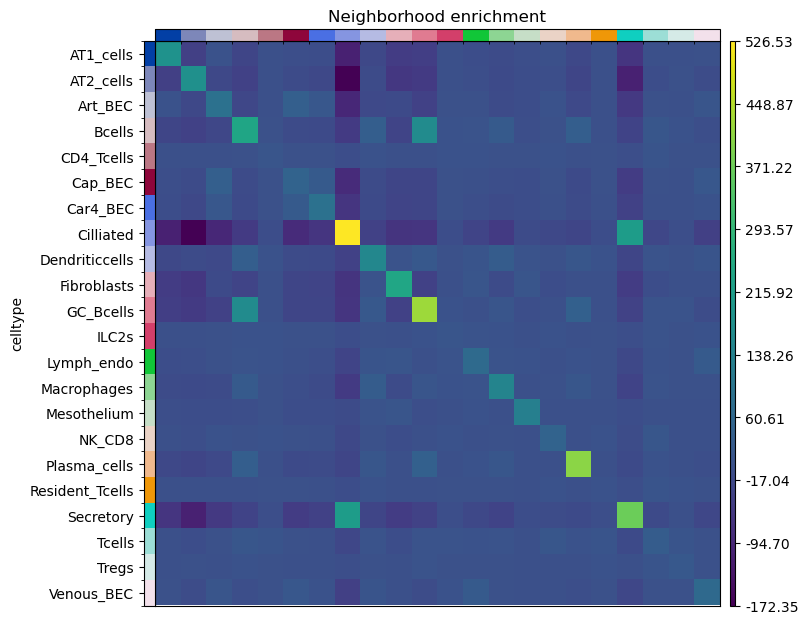

In [64]:
sq.pl.nhood_enrichment(sdata, cluster_key="celltype", figsize=(6,6))
